# 📘Week 6 Assignment — Autoencoder for Image Denoising
**Topics Covered:** MNIST Dataset,Autoencoders,Noise,FFNN,CNN and MSE 
---
In this assignment, I'll be working upon two denoising autoencoders on the MNIST dataset — one using a simple dense network (FFNN) and one using convolutions (CNN). The idea is to add noise to the images and train the models to recover the clean version.

## Pipeline

1. Import required libraries
2. Load and preprocess the MNIST dataset
3. Add noise to create noisy input images
4. Visualize original vs noisy images
5. Define FFNN and CNN Autoencoder architectures
6. Define loss function and optimizer
7. Train both models using noisy images as input and clean images as targets
8. Plot training and validation loss curves
9. Generate denoised outputs on the test set
10. Results
11. Conclusion

## 1. Importing Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
print("done")

done


## 2. Loading and Preprocessing the Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("x_train min/max:", x_train.min(), x_train.max())

Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)
x_train min/max: 0.0 1.0


## 3. Adding Noise

In [3]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * np.random.normal(size=images.shape)
    noisy = np.clip(noisy, 0., 1.)
    return noisy

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

## 4. Visualizing Original vs Noisy Images

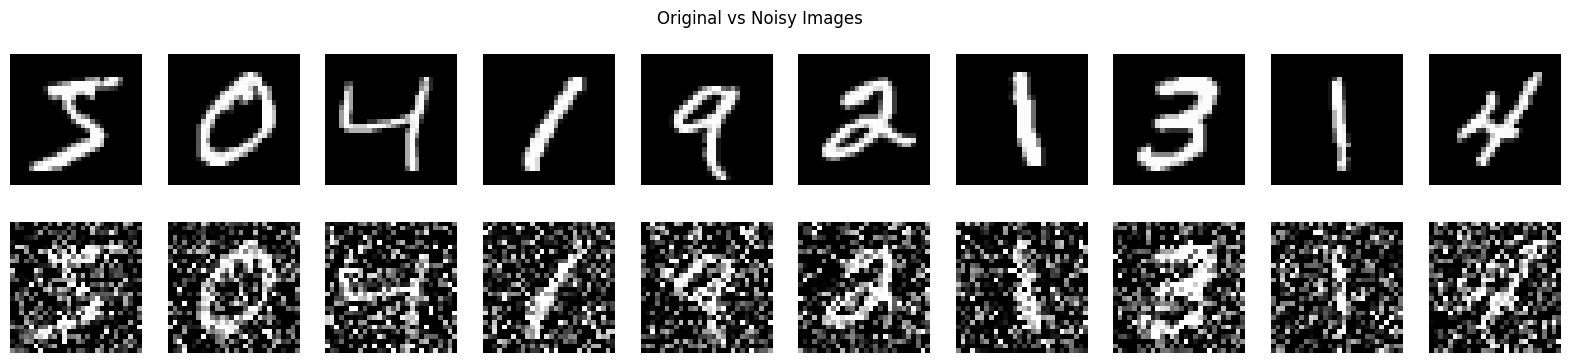

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i in range(10):
    axes[0, i].imshow(x_train[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
  
    axes[1, i].imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Noisy', fontsize=12)
plt.suptitle('Original vs Noisy Images')
plt.show()

## 5. Defining Architecture

In [5]:
ffnn_autoencoder = models.Sequential([
    layers.Input(shape=(784,)),
 
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
 
    layers.Dense(128, activation='relu'),
    layers.Dense(784, activation='sigmoid'),
])

inputs = tf.keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(16, (3,3), strides=2, activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(8, (3,3), strides=2, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)

x = layers.Conv2DTranspose(8, (3,3), strides=2, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(16, (3,3), strides=2, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

cnn_autoencoder = tf.keras.Model(inputs, decoded)

## 6. Defining Loss Function and Optimizer

In [6]:
ffnn_autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')
cnn_autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

## 7. Training

In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

x_train_flat = x_train_noisy.reshape(-1, 784)
x_val_flat = x_train.reshape(-1, 784)

ffnn_history = ffnn_autoencoder.fit(
    x_train_flat, x_val_flat,
    epochs=30,
    batch_size=20,
    validation_split=0.2,
    callbacks=[early_stop]
)

cnn_history = cnn_autoencoder.fit(
    x_train_noisy, x_train,
    epochs=30,
    batch_size=20,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0336 - val_loss: 0.0241
Epoch 2/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0221 - val_loss: 0.0207
Epoch 3/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0197 - val_loss: 0.0192
Epoch 4/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0185 - val_loss: 0.0190
Epoch 5/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0178 - val_loss: 0.0184
Epoch 6/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0173 - val_loss: 0.0180
Epoch 7/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0169 - val_loss: 0.0175
Epoch 8/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0166 - val_loss: 0.0173
Epoch 9/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0163 - val_loss: 0.0171
Epoch 10/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0162 - val_loss: 0.0170
Epoch 11/30
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0160 - val_loss: 0.0168
Epoch 12/30
2400/2400 ━━━━━━━━

## 8. Plotting Loss

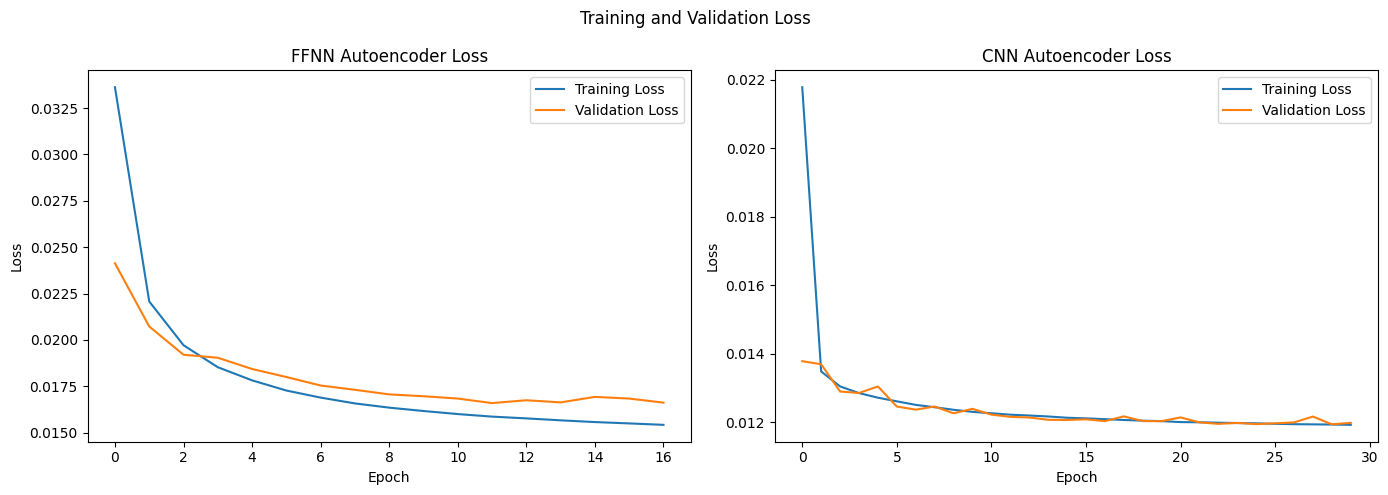

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ffnn_history.history['loss'], label='Training Loss')
axes[0].plot(ffnn_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('FFNN Autoencoder Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(cnn_history.history['loss'], label='Training Loss')
axes[1].plot(cnn_history.history['val_loss'], label='Validation Loss')
axes[1].set_title('CNN Autoencoder Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Training and Validation Loss')
plt.tight_layout()
plt.show()

## 9. Generate Denoised Outputs on the Test Set

In [9]:
x_test_flat = x_test_noisy.reshape(-1, 784)

ffnn_output = ffnn_autoencoder.predict(x_test_flat)
cnn_output = cnn_autoencoder.predict(x_test_noisy)

print("FFNN output shape:", ffnn_output.shape)
print("CNN output shape:", cnn_output.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
FFNN output shape: (10000, 784)
CNN output shape: (10000, 28, 28, 1)


## 10. Results

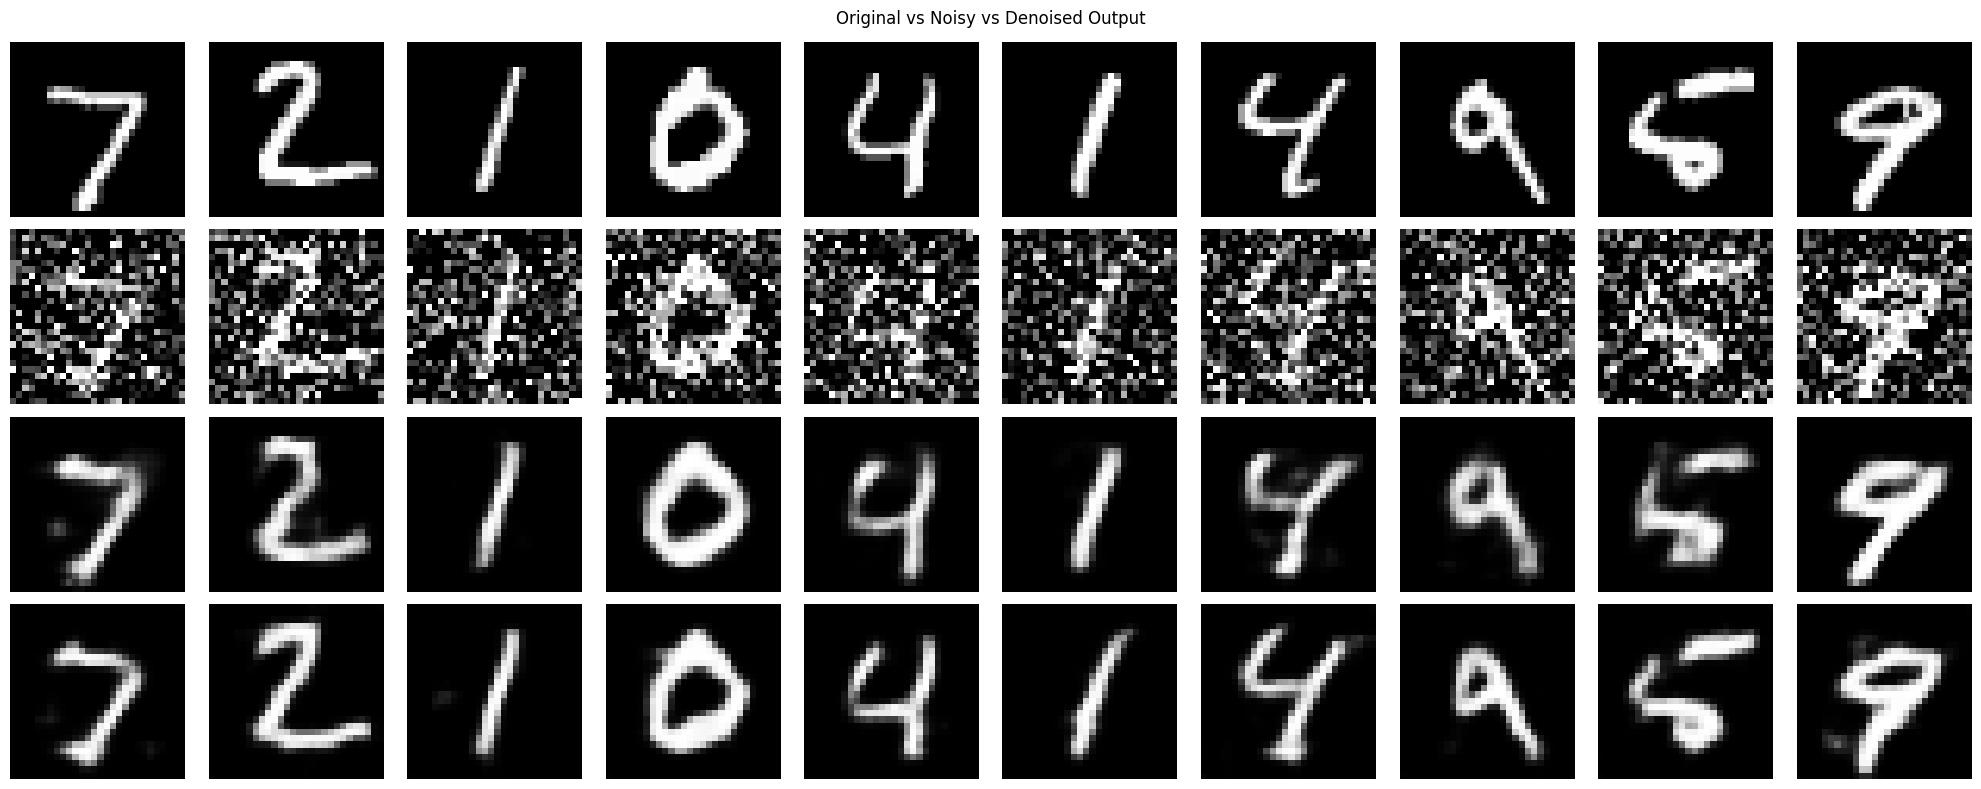

In [10]:
n = 10
fig, axes = plt.subplots(4, n, figsize=(20, 8))

for i in range(n):
    # original
    axes[0, i].imshow(x_test[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    # noisy
    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    # FFNN output
    axes[2, i].imshow(ffnn_output[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    # CNN output
    axes[3, i].imshow(cnn_output[i].reshape(28, 28), cmap='gray')
    axes[3, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Noisy', fontsize=12)
axes[2, 0].set_ylabel('FFNN Output', fontsize=12)
axes[3, 0].set_ylabel('CNN Output', fontsize=12)

plt.suptitle('Original vs Noisy vs Denoised Output')
plt.tight_layout()
plt.show()

## 11. Conclusion


- The FFNN produced blurry reconstructions due to loss of spatial structure from flattening, though digits were mostly identifiable.
- The CNN with BatchNormalization handled the noise well, producing clean sharp reconstructions consistently across 30 epochs.
- CNN clearly outperforms FFNN for image denoising since convolutions preserve spatial features that dense layers can't.